# **🩺 Heart Failure Prediction Dataset**

Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.

### **Attribute Information**

| Attribute | Description | Type / Valid Values |
| :--- | :--- | :--- |
| **Age** | Age of the patient | Years (Numeric) |
| **Sex** | Sex of the patient | `M`: Male<br>`F`: Female |
| **ChestPainType** | Chest pain type | `TA`: Typical Angina<br>`ATA`: Atypical Angina<br>`NAP`: Non-Anginal Pain<br>`ASY`: Asymptomatic |
| **RestingBP** | Resting blood pressure | mm Hg (Numeric) |
| **Cholesterol** | Serum cholesterol | mm/dl (Numeric) |
| **FastingBS** | Fasting blood sugar | `1`: If FastingBS > 120 mg/dl<br>`0`: Otherwise |
| **RestingECG** | Resting electrocardiogram results | `Normal`: Normal<br>`ST`: ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)<br>`LVH`: Probable or definite left ventricular hypertrophy by Estes' criteria |
| **MaxHR** | Maximum heart rate achieved | Numeric value between 60 and 202 |
| **ExerciseAngina** | Exercise-induced angina | `Y`: Yes<br>`N`: No |
| **Oldpeak** | ST depression induced by exercise relative to rest | Numeric value |
| **ST_Slope** | The slope of the peak exercise ST segment | `Up`: Upsloping<br>`Flat`: Flat<br>`Down`: Downsloping |
| **HeartDisease** | Output class (Target variable) | `1`: Heart disease<br>`0`: Normal |

<div style="background-color: rgba(35, 162, 217, 0.18); padding: 10px; border-radius: 5px; border-left: 5px solid #23a2d9;">
  <h2 style="color: #1d8ebf; margin: 0; padding: 0; line-height: 1.2;">Heart Disease Prediction (ML Model)</h2>
</div>
<br>

Predict the likelihood of a patient having heart disease based on clinical, physiological, and diagnostic indicators. The feature set presents a strong mix of demographic baselines (`Age`, `Sex`), metabolic metrics (`Cholesterol`, `FastingBS`), and cardiac stress indicators (`MaxHR`, `Oldpeak`, `ST_Slope`). This setup is highly suited for ensemble methods (e.g., XGBoost, LightGBM) or logistic regression for baseline interpretability

**Sub-targets:**
* Binary Classification (HeartDisease): Predict if the target variable is 1 (Heart Disease) or 0 (Normal).
* High-Risk Segment Identification: Isolate a subset of asymptomatic patients (ChestPainType == ASY) who exhibit high probability scores to catch silent cardiac issues.
* Feature Importance Ranking: Quantify whether electro-physiological markers (ST_Slope, Oldpeak) carry more predictive weight than traditional risk factors (Cholesterol, RestingBP).


**Areas of Focus for Exploration**
1. Encoding & Preprocessing: Use One-Hot Encoding for nominal categorical features (ChestPainType, RestingECG) and Target/Label Encoding for ordinal ones (ST_Slope).
2. Handle Anomalies Gently: Look out for zero-value anomalies in Cholesterol or RestingBP (common in Kaggle's combined heart disease sets). Decide whether to impute them via KNN Imputer or drop them, as a cholesterol level of 0 is physiological nonsense.
3. Model Explainability (SHAP/LIME): Because this is a medical context, pure accuracy isn't enough. Use SHAP values to explain why the model flags a patient. For instance, show how an asymptomatic (ASY) patient with a downsloping ST_Slope drives up the risk score.
4. Optimize for Recall: In clinical diagnostic pipelines, false negatives are significantly more dangerous than false positives. Tune your classification threshold to optimize the Recall (Sensitivity) or $F_\beta$ score (where $\beta = 2$) rather than just raw accuracy.

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [4]:
data = pd.read_csv('/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv')

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
data.shape

(918, 12)

In [6]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
data.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## **Data Exploration & EDA**

* High-Risk Segment Identification: Isolate a subset of asymptomatic patients (ChestPainType == ASY) who exhibit high probability scores to catch silent cardiac issues.
* Feature Importance Ranking: Quantify whether electro-physiological markers (ST_Slope, Oldpeak) carry more predictive weight than traditional risk factors (Cholesterol, RestingBP).

In [20]:
heart_disease = data[data['HeartDisease'] == 1]
heart_disease

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
11,58,M,ATA,136,164,0,ST,99,Y,2.0,Flat,1
13,49,M,ASY,140,234,0,Normal,140,Y,1.0,Flat,1
...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1


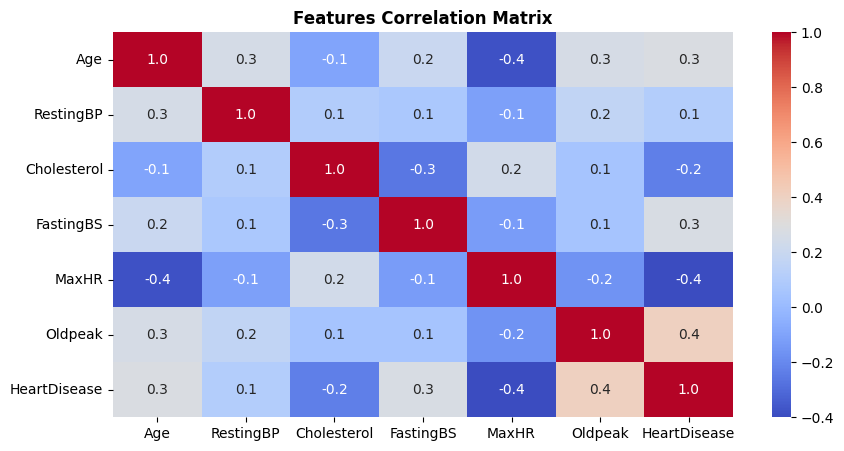

In [18]:
corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize = (10,5))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".1f")
plt.title('Features Correlation Matrix', fontweight="bold")
plt.show()

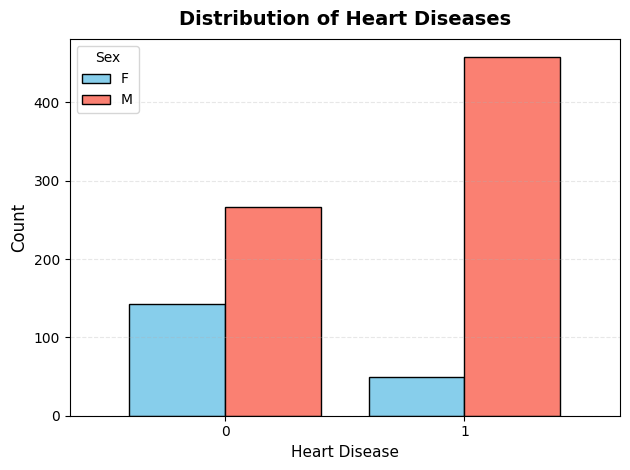

In [45]:
counts = data.groupby(['HeartDisease', 'Sex']).size().unstack(fill_value=0)

ax = counts.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black', width=0.8)

plt.title("Distribution of Heart Diseases", fontsize=14, pad=10, fontweight='bold')
plt.xlabel("Heart Disease", fontsize=11)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Sex")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
data[data['HeartDisease'] == 0].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.0
mean,50.551220,130.180488,227.121951,0.107317,148.151220,0.408049,0.0
std,9.444915,16.499585,74.634659,0.309894,23.288067,0.699709,0.0
min,28.000000,80.000000,0.000000,0.000000,69.000000,-1.100000,0.0
25%,43.000000,120.000000,197.250000,0.000000,134.000000,0.000000,0.0
50%,51.000000,130.000000,227.000000,0.000000,150.000000,0.000000,0.0
75%,57.000000,140.000000,266.750000,0.000000,165.000000,0.600000,0.0
max,76.000000,190.000000,564.000000,1.000000,202.000000,4.200000,0.0


In [75]:
heart_disease.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,508.000000,508.000000,508.000000,508.000000,508.000000,508.000000,508.0
mean,55.899606,134.185039,175.940945,0.334646,127.655512,1.274213,1.0
std,8.727056,19.828685,126.391398,0.472332,23.386923,1.151872,0.0
min,31.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,1.0
25%,51.000000,120.000000,0.000000,0.000000,112.000000,0.000000,1.0
50%,57.000000,132.000000,217.000000,0.000000,126.000000,1.200000,1.0
75%,62.000000,145.000000,267.000000,1.000000,144.250000,2.000000,1.0
max,77.000000,200.000000,603.000000,1.000000,195.000000,6.200000,1.0


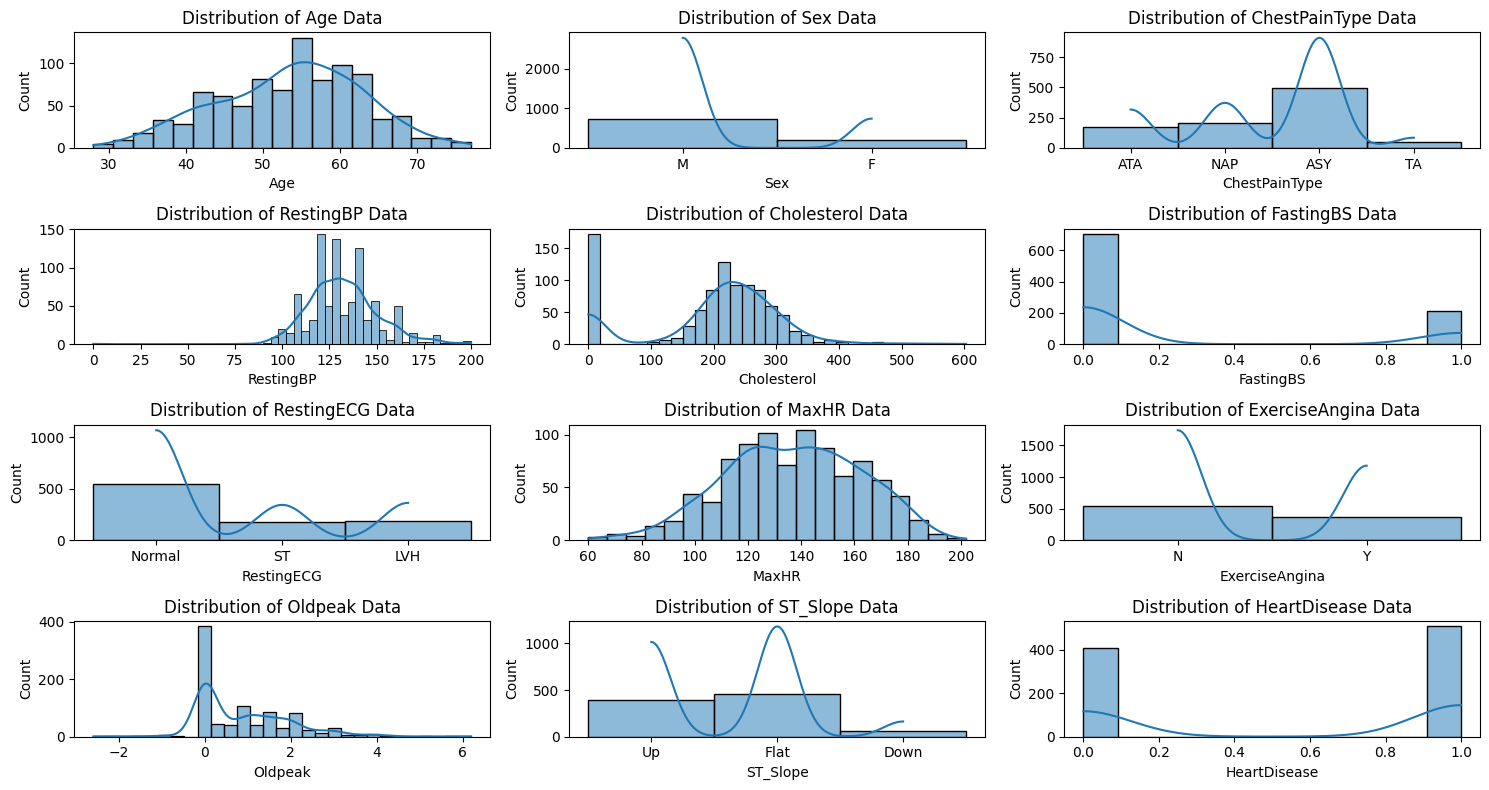

In [53]:
plt.figure(figsize=(15,8))
for i,col in enumerate(data.columns,1):
    plt.subplot(4,3,i)
    plt.title(f"Distribution of {col} Data")
    sns.histplot(data[col],kde=True)
    plt.tight_layout()
    plt.plot()

### **Data Distribution**
- Most data recorded from age of 50-60 years
- Most data recorded from male individuals
- Greatest count of chest pain type is Asymptomatic
- Spikes for Resting BP at 115, 130-140
- Most cholesterol recorded at 0 mm, and then greater mean at 210-230
- Mostly normal Resting ECG

and more


### **Mean Value Comparisons for Heart Disease Patients and Non-Heart Disease Patients**
* The average age of a non-heart disease individual is 50.55 years where as the patients of heart disease have average age of 55.89 years
* The resting BP for a non-heart disease patient is 130.18 compared to 134.18 for a heart disease patient
* The average cholestrol is higher for a non-heart disease patient at 227.12 compared to a 175.94
* The fasting BS is slightly higher for heart disease patients at 0.33 compared to a non-heart disease patient at 0.107
* The Max HR for a non-heart disease patient is higher at 148.15 compared to 127.65
* The Oldpeak (whether the heart is getting enough blood) is very high for a heart disease patient at 1.27 compared to 0.408


Here is how a doctor evaluates these attributes, ranked by their expected predictive importance in a machine learning model :

### **High Importance (The Heaviest Weights)**
**`ST_Slope` (The Peak Exercise ST Segment)**
* **Medical Reason:** An upsloping ST segment is generally a normal response to exercise. A flat or downsloping segment indicates severe myocardial ischemia (the heart muscle is starved for oxygen because blood flow is restricted by blocked arteries).


**`ChestPainType` (Specifically `ASY` - Asymptomatic)**
* **Medical Reason:** In this dataset, a patient being asymptomatic (`ASY`) while displaying other abnormal stress markers is highly predictive of advanced, undetected coronary artery disease.


**`Oldpeak` (ST Depression Induced by Exercise)**
* **Medical Reason:** The higher the depression value, the greater the structural and functional strain on the left ventricle under stress, making it a stark mathematical separator between healthy and ischemic hearts.


**`MaxHR` (Maximum Heart Rate Achieved)**
* **Medical Reason:** A healthy heart can beat faster under physical stress to pump oxygenated blood efficiently. If a patient's maximum heart rate is abnormally low during exercise (chronotropic incompetence), it signals that the heart muscle or its conduction system is failing to meet metabolic demands.



### **Medium Importance (The Aggravating Risk Factors)**
**`Age`**
* **Medical Reason:** Cardiovascular infrastructure naturally degrades over time due to arterial stiffening and plaque accumulation. Risk accelerates sharply after age 50, making it a highly reliable baseline structural weight for the model.


**`ExerciseAngina` (Exercise-Induced Chest Pain)**
* **Medical Reason:** If a patient experiences angina specifically during exertion, it confirms a classic supply-demand mismatch in coronary blood flow. It acts as an excellent confirmatory feature alongside `Oldpeak` and `ST_Slope`.


**`RestingECG` (Resting Electrocardiogram Results)**
* **Medical Reason:** Anomalies at rest like `ST` wave abnormalities or Left Ventricular Hypertrophy (`LVH` - a thickened heart wall from fighting high blood pressure) show that structural damage has already occurred. However, it ranks below exercise features because many heart disease patients have a completely normal ECG at rest.


**`FastingBS` (Fasting Blood Sugar)**
* **Medical Reason:** Diabetes mellitus fundamentally alters lipid metabolism and aggressively accelerates endothelial damage (scarring the inner lining of blood vessels). It serves as a strong proxy feature for underlying systemic vascular decay.

## **Data Preprocessing**

In [56]:
data.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [58]:
data.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## **ML Model Development**

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

In [67]:
# 1. Separate features and target
X = data.drop(columns=['HeartDisease'])
y = data['HeartDisease']

# 2. Split into train and test sets first to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Define which columns get which treatment
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
# Note: FastingBS is already 0 or 1, so it can bypass both transformers if desired

# 4. Create the preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    # Good place to add a KNNImputer(missing_values=0) for cholesterol later
    ('scaler', StandardScaler()) 
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore')) # drop='first' avoids multicollinearity
])

# 5. Combine them into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough',
    force_int_remainder_cols=False
)

# 6. Bundle preprocessing and the model together
# avoids overfitting training accuracy of 1.00 with constraints
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=150,       # Increased from 100 to smooth out predictions via more trees
        max_depth=6,            # Prevents trees from growing deep enough to memorize anomalies
        min_samples_split=5,    # Requires at least 5 samples in a node to consider splitting it
        min_samples_leaf=4,     # Guarantees each leaf has at least 4 samples, smoothing boundaries
        random_state=42
    ))
])

# 7. Fit the entire pipeline seamlessly
model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'MaxHR',
                                                   'Oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=6, min_samples_leaf=4,
                                        min_samples_split=5, n_estimators=150,
                                        random_state=42))])

In [65]:
# Evaluate
print(f"Training Accuracy: {model_pipeline.score(X_train, y_train):.4f}")
print(f"Testing Accuracy: {model_pipeline.score(X_test, y_test):.4f}")

Training Accuracy: 0.8965
Testing Accuracy: 0.8641


In [66]:
from sklearn.metrics import classification_report

# 1. Generate predictions using your trained pipeline
y_pred = model_pipeline.predict(X_test)

# 2. Generate and print the comprehensive report
# target_names maps the 0 and 1 back to human-readable strings
report = classification_report(y_test, y_pred, target_names=['Normal (0)', 'Heart Disease (1)'])

print("--- Random Forest Performance Metrics ---")
print(report)

--- Random Forest Performance Metrics ---
                   precision    recall  f1-score   support

       Normal (0)       0.87      0.82      0.84        82
Heart Disease (1)       0.86      0.90      0.88       102

         accuracy                           0.86       184
        macro avg       0.86      0.86      0.86       184
     weighted avg       0.86      0.86      0.86       184



## **Model Evaluation and Confusion Matrix**

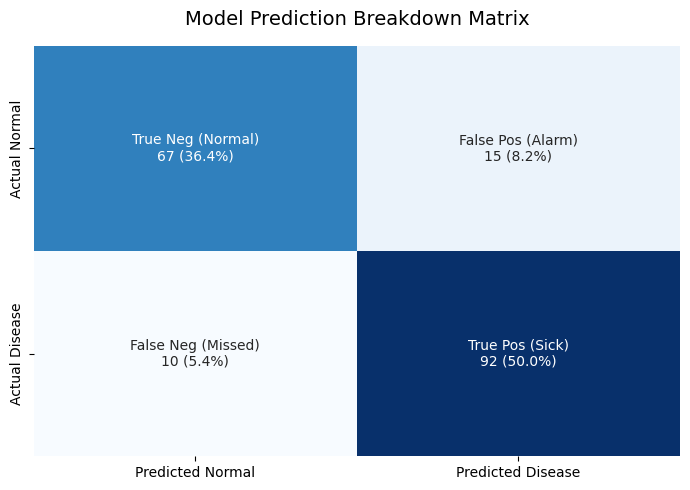

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Define layout labels
labels = ['True Neg (Normal)\n', 'False Pos (Alarm)\n', 'False Neg (Missed)\n', 'True Pos (Sick)\n']
counts = [f"{value:0.0f}" for value in cm.flatten()]
percentages = [f"{value:.1%}" for value in cm.flatten() / cm.sum()]

box_labels = [f"{v1}{v2} ({v3})" for v1, v2, v3 in zip(labels, counts, percentages)]
box_labels = np.asarray(box_labels).reshape(2,2)

# 3. Plot Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=box_labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Disease'],
            yticklabels=['Actual Normal', 'Actual Disease'])

plt.title('Model Prediction Breakdown Matrix', fontsize=14, pad=15)
plt.tight_layout()
plt.show()